Overall:
    - 202,599 face images
    - 10,177 unique identities
    - images size 178x218
    - 40 binary attribute labels per image (e.g., gender, accessories)
    - 5 landmark points (left eye, right eye, nose, left mouth, right mouth)
Datafile:
    - list_attr_celeba.csv: Attribute labels for each image.
    - list_bbox_celeba.csv: Bounding box information for each image
    - list_eval_partition.csv: Recommended partitioning of images into training, validation, testing sets
    - list_landmarks_align_celeba.csv: Image landmarks and their respective coordinates


Image recognition is one of the many applications of Machine Learning, it can solve problems for security purposes, object detection, face detection, healthcare, entertainment, among others. This application has an enormous potential to help our society, so it is important to find new uses for this tool, improve the current methods and get more accurate and useful insights from it. A good example of these applications, is the work done by research of The Chinese University of Hong Kong for face detection using deep learning (https://arxiv.org/abs/1509.06451).

In this project, we will build a Machine Learning Algorithm using CNN to predict from a giving picture if the celebrity is male or female.

A popular component of computer vision and deep learning revolves around identifying faces for various applications from logging into your phone with your face or searching through surveillance images for a particular suspect. This dataset is great for training and testing models for face detection, particularly for recognising facial attributes such as finding people with brown hair, are smiling, or wearing glasses. Images cover large pose variations, background clutter, diverse people, supported by a large quantity of images and rich annotations. This data was originally collected by researchers at MMLAB, The Chinese University of Hong Kong (specific reference in Acknowledgment section).

Data Files
img_align_celeba.zip: All the face images, cropped and aligned
list_eval_partition.csv: Recommended partitioning of images into training, validation, testing sets. Images 1-162770 are training, 162771-182637 are validation, 182638-202599 are testing
list_bbox_celeba.csv: Bounding box information for each image. "x_1" and "y_1" represent the upper left point coordinate of bounding box. "width" and "height" represent the width and height of bounding box
list_landmarks_align_celeba.csv: Image landmarks and their respective coordinates. There are 5 landmarks: left eye, right eye, nose, left mouth, right mouth
list_attr_celeba.csv: Attribute labels for each image. There are 40 attributes. "1" represents positive while "-1" represents negative

In [507]:
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt#plotting
from PIL import Image, ImageDraw
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import cv2    

from keras.applications.inception_v3 import InceptionV3, preprocess_input
from keras import optimizers
from keras.models import Sequential, Model 
from keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras.utils import to_categorical
from keras.optimizers import SGD
from IPython.display import display, HTML
from io import BytesIO
import base64

plt.style.use('ggplot')

%matplotlib inline
import tensorflow as tf
print(tf.__version__)

2.16.2


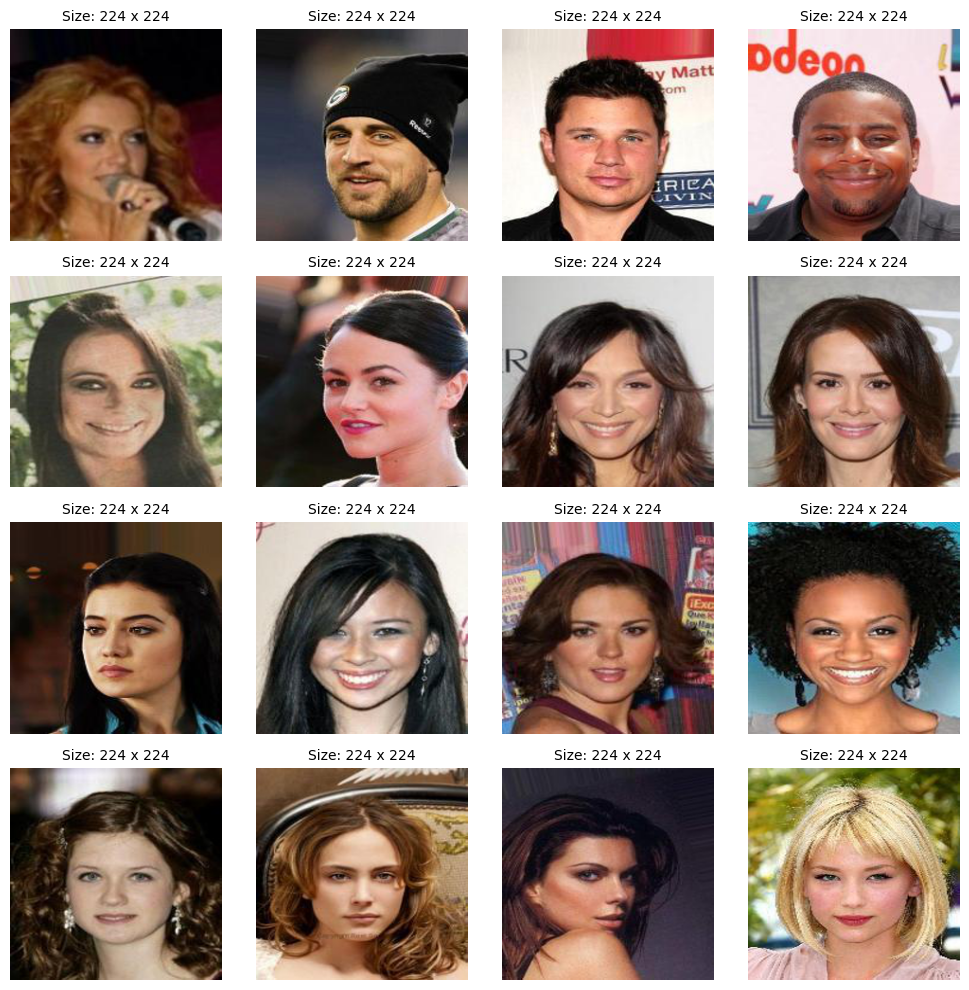

In [509]:
folder_path = '/Users/steffidorothy/Downloads/KDD/archive (2)/img_align_celeba/img_align_celeba'

image_files = os.listdir(folder_path)
random_images = random.sample(image_files, 20)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
images = []
for ax, img_file in zip(axes.flatten(), random_images):
    img_path = os.path.join(folder_path, img_file)
    img = Image.open(img_path).resize((224, 224))
    image_array = np.array(img) / 255.0  # Normalize pixel values
    images.append(image_array)
    img_size = img.size
    ax.imshow(img)
    ax.axis('off')  
    ax.set_title(f'Size: {img_size[0]} x {img_size[1]}', fontsize=10)

plt.tight_layout()
plt.show()

In [511]:
df_attr=pd.read_csv('/Users/steffidorothy/Downloads/KDD/archive (2)/list_attr_celeba.csv')
df_bbox=pd.read_csv('/Users/steffidorothy/Downloads/KDD/archive (2)/list_bbox_celeba.csv')
df_eval=pd.read_csv('/Users/steffidorothy/Downloads/KDD/archive (2)/list_eval_partition.csv')
df_landmarks=pd.read_csv('/Users/steffidorothy/Downloads/KDD/archive (2)/list_landmarks_align_celeba.csv')

In [513]:
df_attr

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202594,202595.jpg,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
202595,202596.jpg,-1,-1,-1,-1,-1,1,1,-1,-1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
202596,202597.jpg,-1,-1,-1,-1,-1,-1,-1,-1,1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
202597,202598.jpg,-1,1,1,-1,-1,-1,1,-1,1,...,-1,1,-1,1,1,-1,1,-1,-1,1


In [515]:
df_attr.columns

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young'],
      dtype='object')

Check for missing values

In [518]:
missing_values=df_attr.isnull().sum()
print(missing_values)

image_id               0
5_o_Clock_Shadow       0
Arched_Eyebrows        0
Attractive             0
Bags_Under_Eyes        0
Bald                   0
Bangs                  0
Big_Lips               0
Big_Nose               0
Black_Hair             0
Blond_Hair             0
Blurry                 0
Brown_Hair             0
Bushy_Eyebrows         0
Chubby                 0
Double_Chin            0
Eyeglasses             0
Goatee                 0
Gray_Hair              0
Heavy_Makeup           0
High_Cheekbones        0
Male                   0
Mouth_Slightly_Open    0
Mustache               0
Narrow_Eyes            0
No_Beard               0
Oval_Face              0
Pale_Skin              0
Pointy_Nose            0
Receding_Hairline      0
Rosy_Cheeks            0
Sideburns              0
Smiling                0
Straight_Hair          0
Wavy_Hair              0
Wearing_Earrings       0
Wearing_Hat            0
Wearing_Lipstick       0
Wearing_Necklace       0
Wearing_Necktie        0


In [520]:
df_attr.index

RangeIndex(start=0, stop=202599, step=1)

In [522]:
df_eval.index

RangeIndex(start=0, stop=202599, step=1)

In [524]:
missing_values=df_eval.isnull().sum()
print(missing_values)

image_id     0
partition    0
dtype: int64


In [526]:
merged_df = df_eval.join(df_attr['Male'], how='inner')
print(merged_df)

          image_id  partition  Male
0       000001.jpg          0    -1
1       000002.jpg          0    -1
2       000003.jpg          0     1
3       000004.jpg          0    -1
4       000005.jpg          0    -1
...            ...        ...   ...
202594  202595.jpg          2    -1
202595  202596.jpg          2     1
202596  202597.jpg          2     1
202597  202598.jpg          2    -1
202598  202599.jpg          2    -1

[202599 rows x 3 columns]


Distribution Of Gender

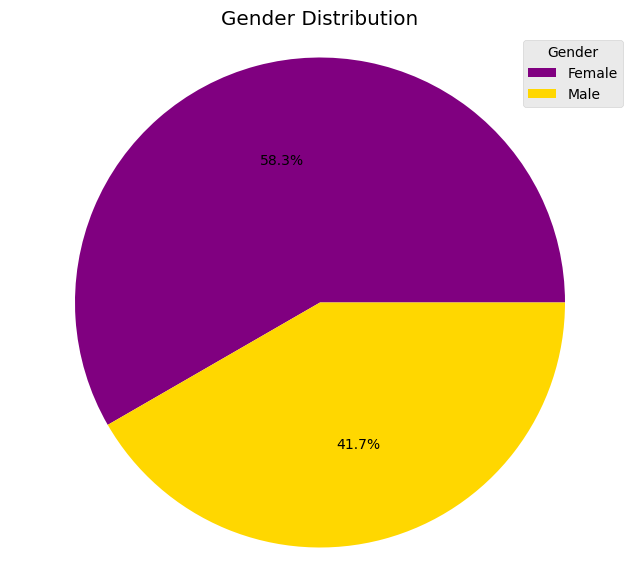

In [582]:
gender_counts=df_attr['Male'].value_counts()
gender_counts.index=['Female','Male']
plt.figure(figsize=(8,7))
plt.pie(gender_counts, colors=['purple','gold'], autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.axis('Equal')
plt.legend(gender_counts.index, title='Gender')
plt.show()

KeyError: '000506.jpg'

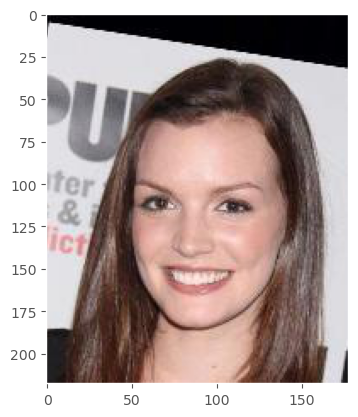

In [584]:
# plot picture and attributes
img = load_img(EXAMPLE_PIC)
plt.grid(False)
plt.imshow(img)
df_attr.loc[EXAMPLE_PIC.split('/')[-1]][['Smiling','Male','Young']] #some attributes

Distribution Of Attributes

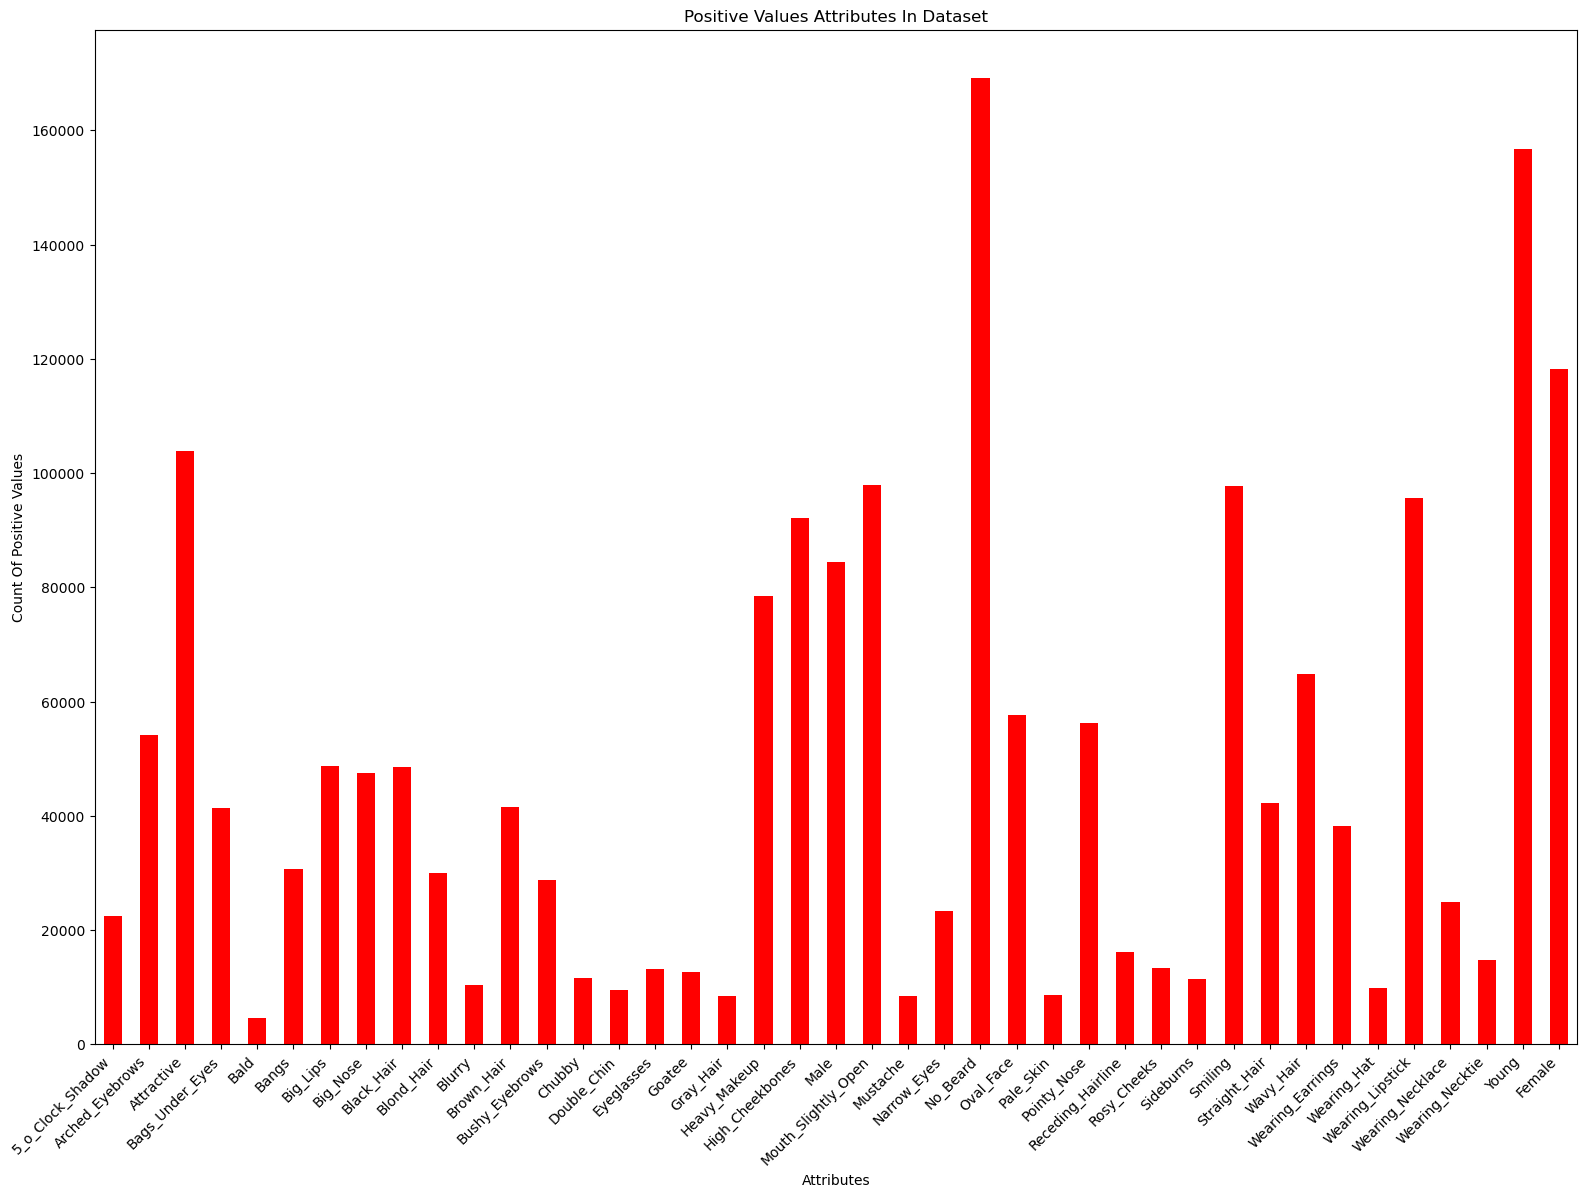

In [397]:
attributes_df=df_attr.drop(columns=['image_id'])
count_ones=(attributes_df==1).sum()
#Calculate the number of males and females
male_count=(attributes_df['Male']==1).sum()
female_count=(attributes_df['Male']==-1).sum()
#Add column female
count_ones['Female']=female_count
#Plot
plt.figure(figsize=(16,15))
count_ones.plot(kind='bar', color='red')
plt.title('Positive Values Attributes In Dataset')
plt.xlabel('Attributes')
plt.ylabel('Count Of Positive Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

This dataset is about celebrities, including many famous actors around the world. As a result, the "Young" and "Attractive" columns have relatively high counts. The dataset predominantly features female, and not every male has facial hair, which explains why the "No Beard" column has the highest count among the male attributes.

Correlation Matrix Of Attributes

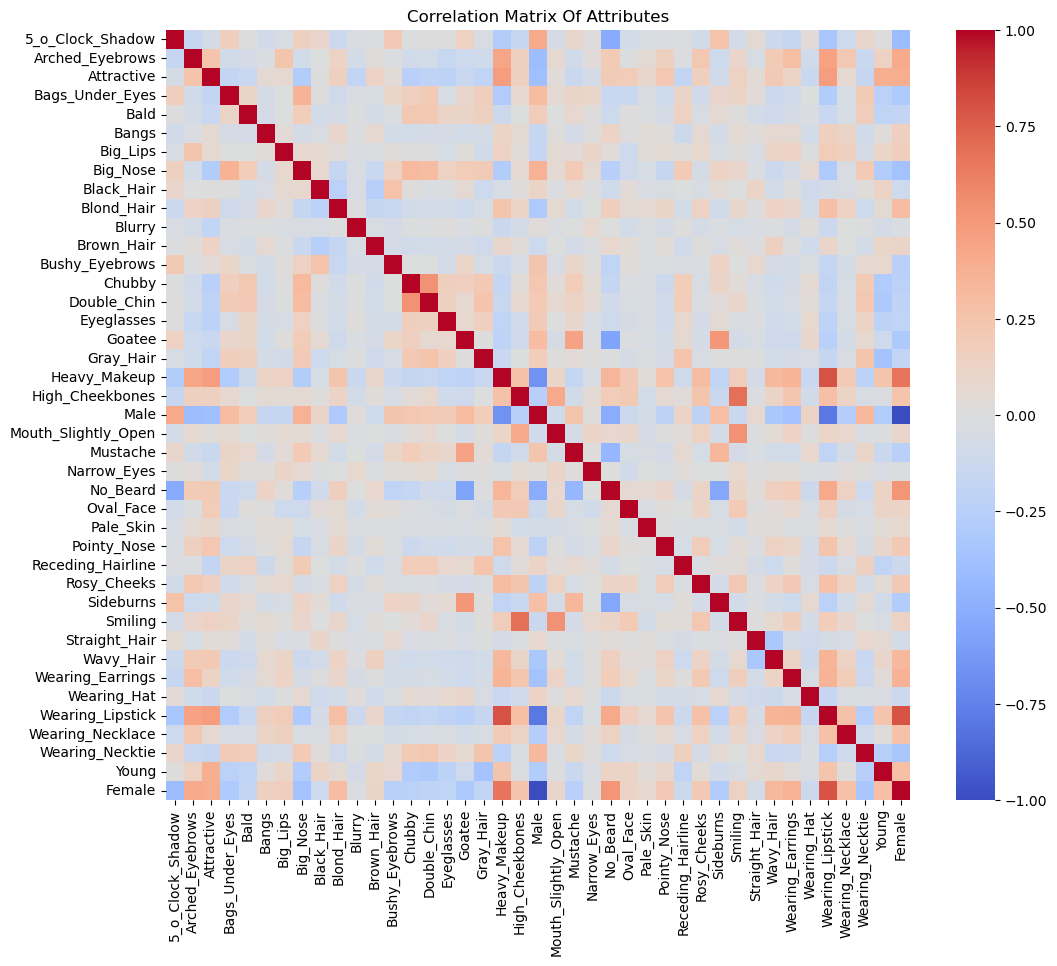

In [308]:
df_attr['Female']=df_attr['Male'].apply(lambda x:-1 if x==1 else 1)
binary_columns=df_attr.columns[1:]
plt.figure(figsize=(12, 10))
corr_matrix=df_attr[binary_columns].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix Of Attributes')
plt.show()           

In [310]:
#Scatter and density plots
def plotscattermatrix(df, plotsize, textsize):
    #keep only numerical columns
    df=df.select_dtypes(include=[np.number])
    #keep columns which have more than one unique columns
    df=df[[col for col in df if df[col].nunique()>1]]
    columnnames=list(df)
    #reduce the number of columns for matrix inversion of kernel density plots
    if len (columnnames)>10:
        columnnames=columnnames[:10]
    df=df[columnnames]
    ax=pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotsize , plotsize], diagonal='kde')
    corrs=df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k=1)):
        ax[i,j].annotate('Corr.coef=%.3f' %corrs[i,j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textsize)
    plt.suptitle('Scatter And Density Plot')
    plt.show()

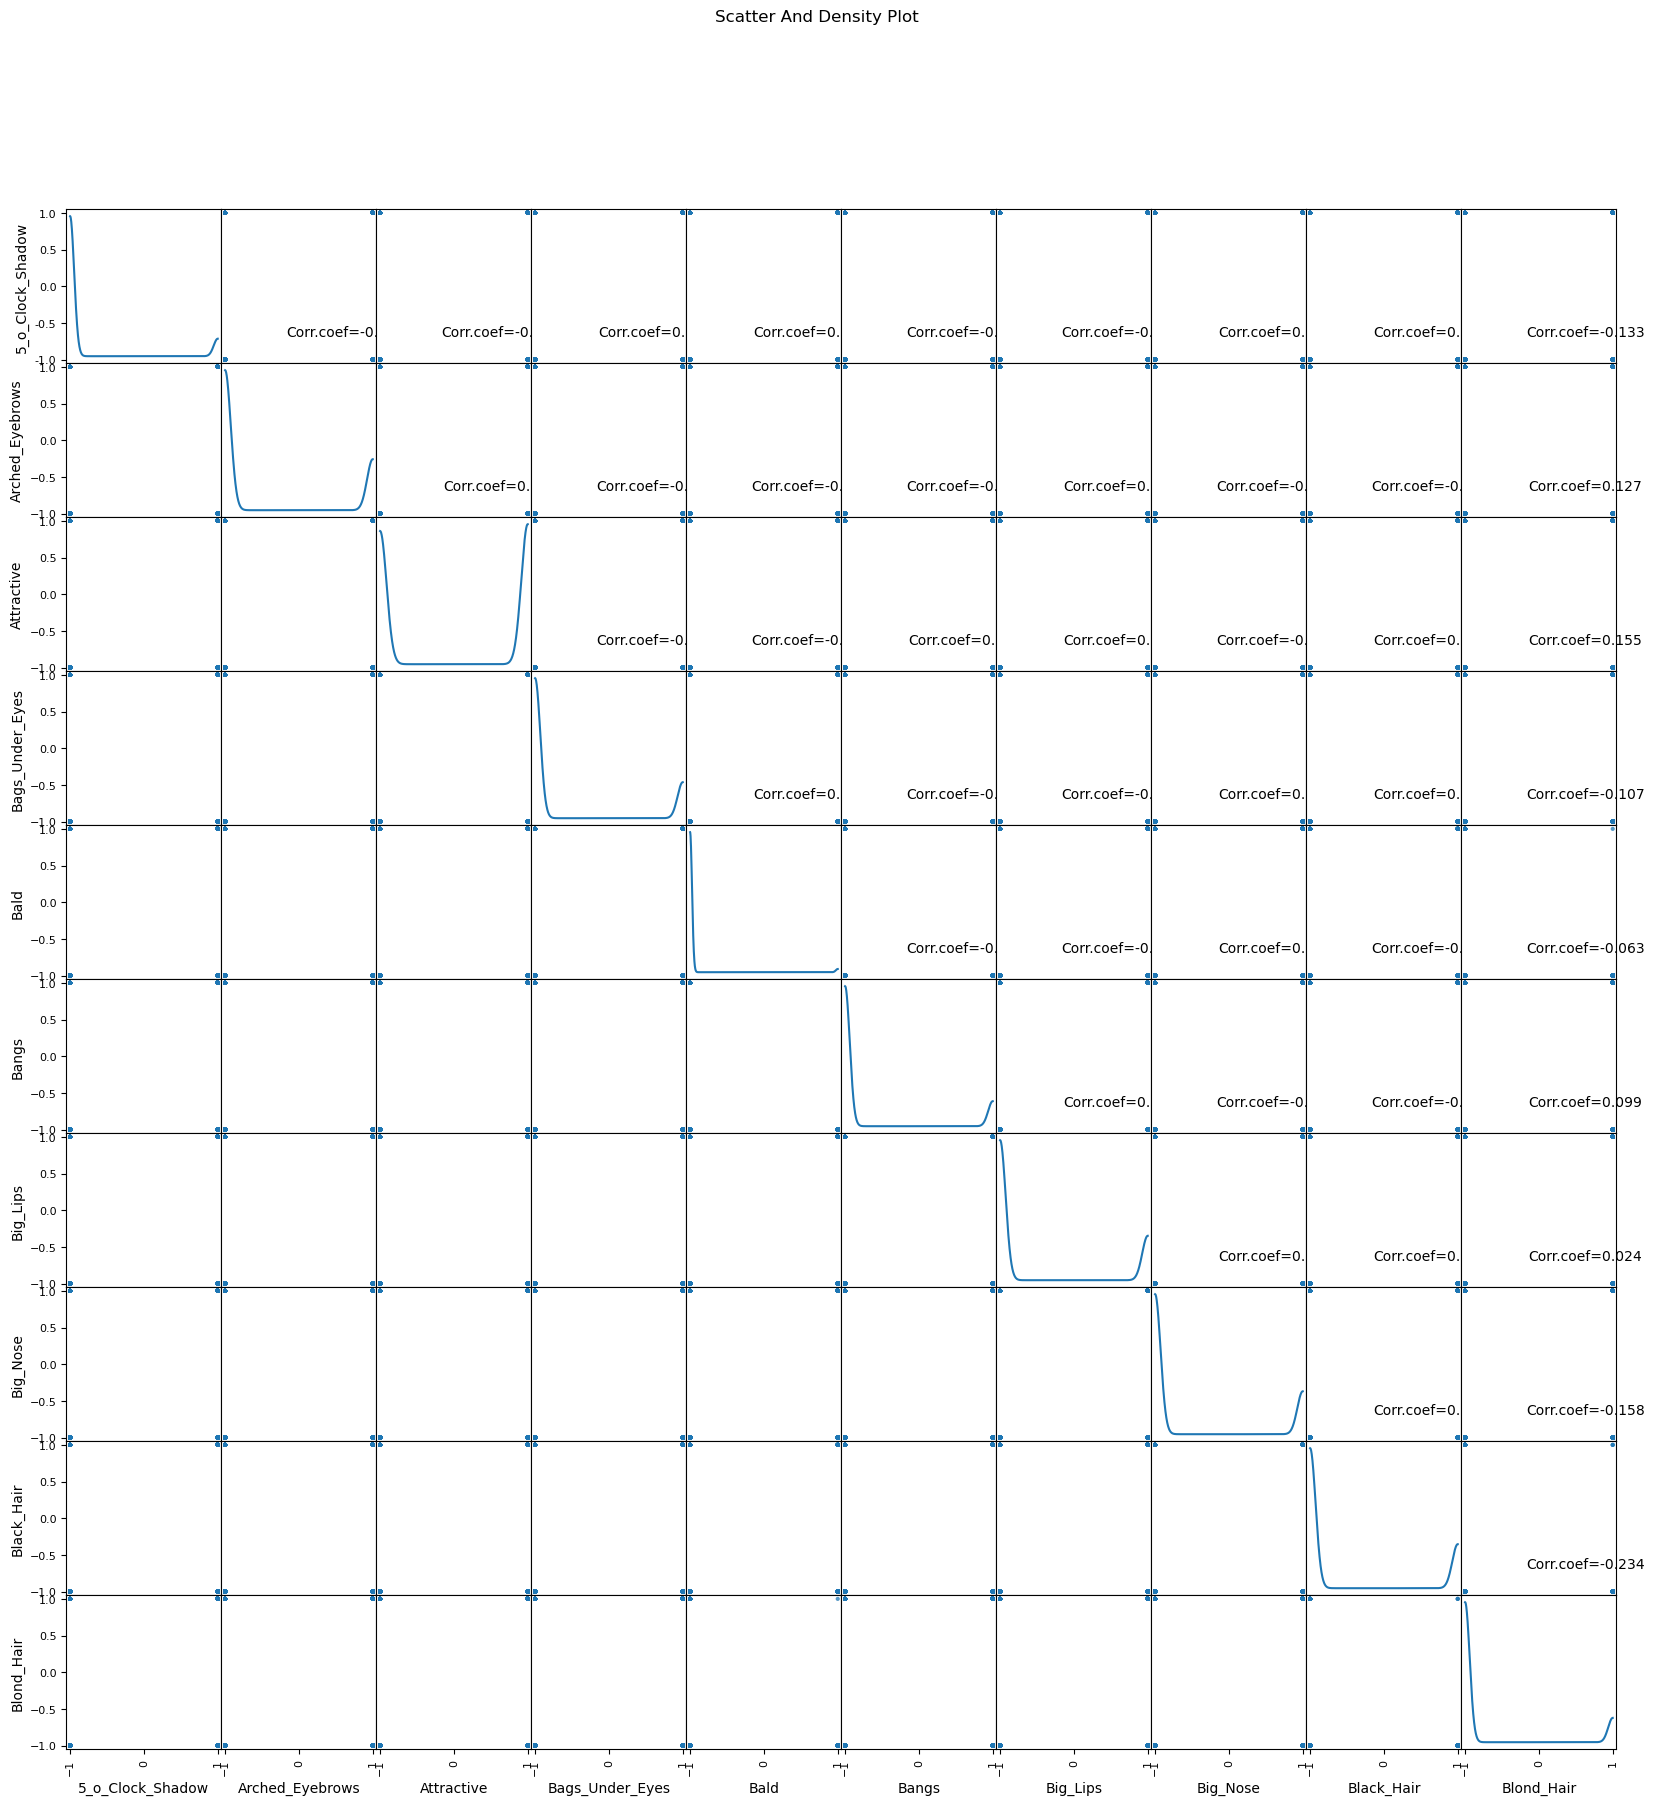

In [26]:
plotscattermatrix(df_attr, 20, 10)

In [27]:
df_bbox

,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166
...,...,...,...,...,...
202594,202595.jpg,1381,91,221,306
202595,202596.jpg,137,129,114,158
202596,202597.jpg,53,76,91,126
202597,202598.jpg,195,28,91,126


In [28]:
filtered_df=df_bbox[(df_bbox['width']>178)|(df_bbox['height']>218)]
print(filtered_df)

          image_id   x_1  y_1  width  height
0       000001.jpg    95   71    226     313
1       000002.jpg    72   94    221     306
3       000004.jpg   622  257    564     781
5       000006.jpg   146   67    182     252
6       000007.jpg    64   93    211     292
...            ...   ...  ...    ...     ...
202590  202591.jpg   700  452   1045    1447
202592  202593.jpg    92  103    190     263
202593  202594.jpg   108  127    244     338
202594  202595.jpg  1381   91    221     306
202598  202599.jpg   101  101    179     248

[107695 rows x 5 columns]


In [29]:
df_bbox.describe()

,x_1,y_1,width,height
count,202599.000000,202599.000000,202599.000000,202599.000000
mean,156.764564,84.335505,194.754061,268.922329
std,164.518135,76.067284,141.770066,195.664936
min,1.000000,0.000000,0.000000,0.000000
25%,69.000000,44.000000,120.000000,166.000000
50%,110.000000,68.000000,164.000000,227.000000
75%,181.000000,98.000000,221.000000,306.000000
max,3840.000000,1858.000000,3827.000000,5299.000000


Width and height of bounding boxes

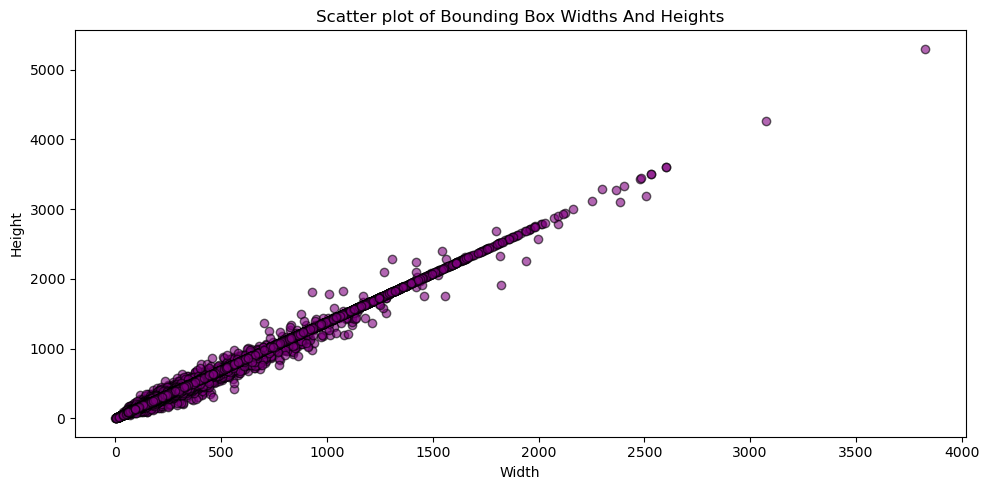

In [31]:
plt.figure(figsize=(10,5))
plt.scatter(df_bbox['width'],df_bbox['height'], alpha=0.6, color='purple', edgecolor='black')
plt.title('Scatter plot of Bounding Box Widths And Heights')
plt.xlabel('Width')
plt.ylabel('Height')
plt.tight_layout()
plt.show()

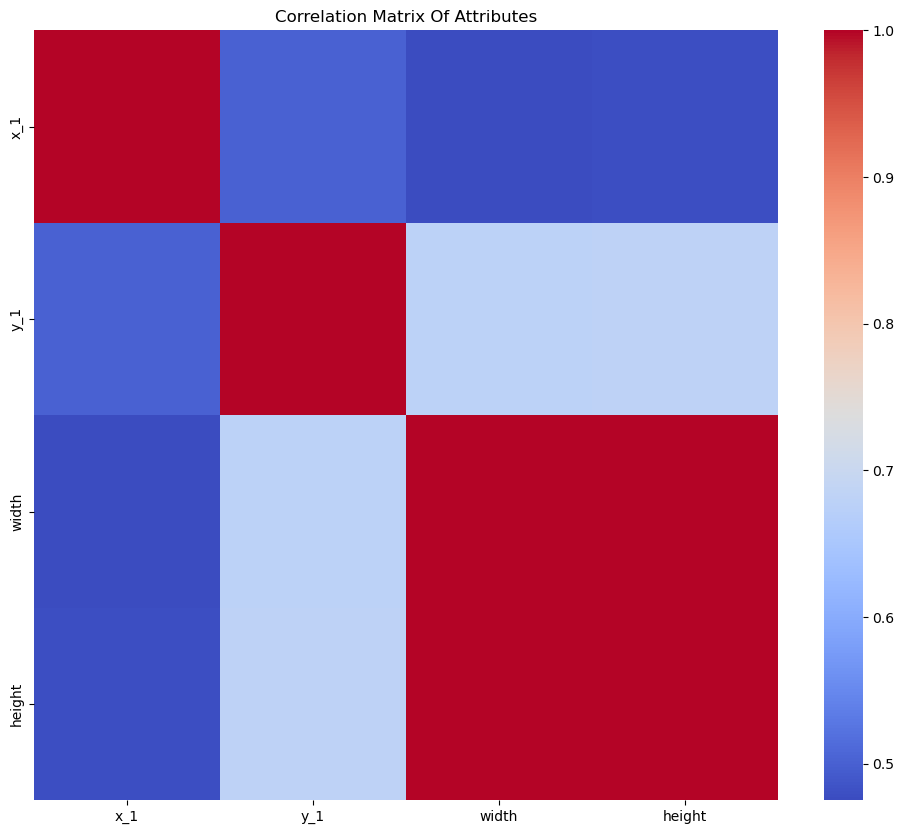

In [32]:
#Correlation matrix
binary_columns=df_bbox.columns[1:]
plt.figure(figsize=(12, 10))
corr_matrix=df_bbox[binary_columns].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix Of Attributes')
plt.show()           

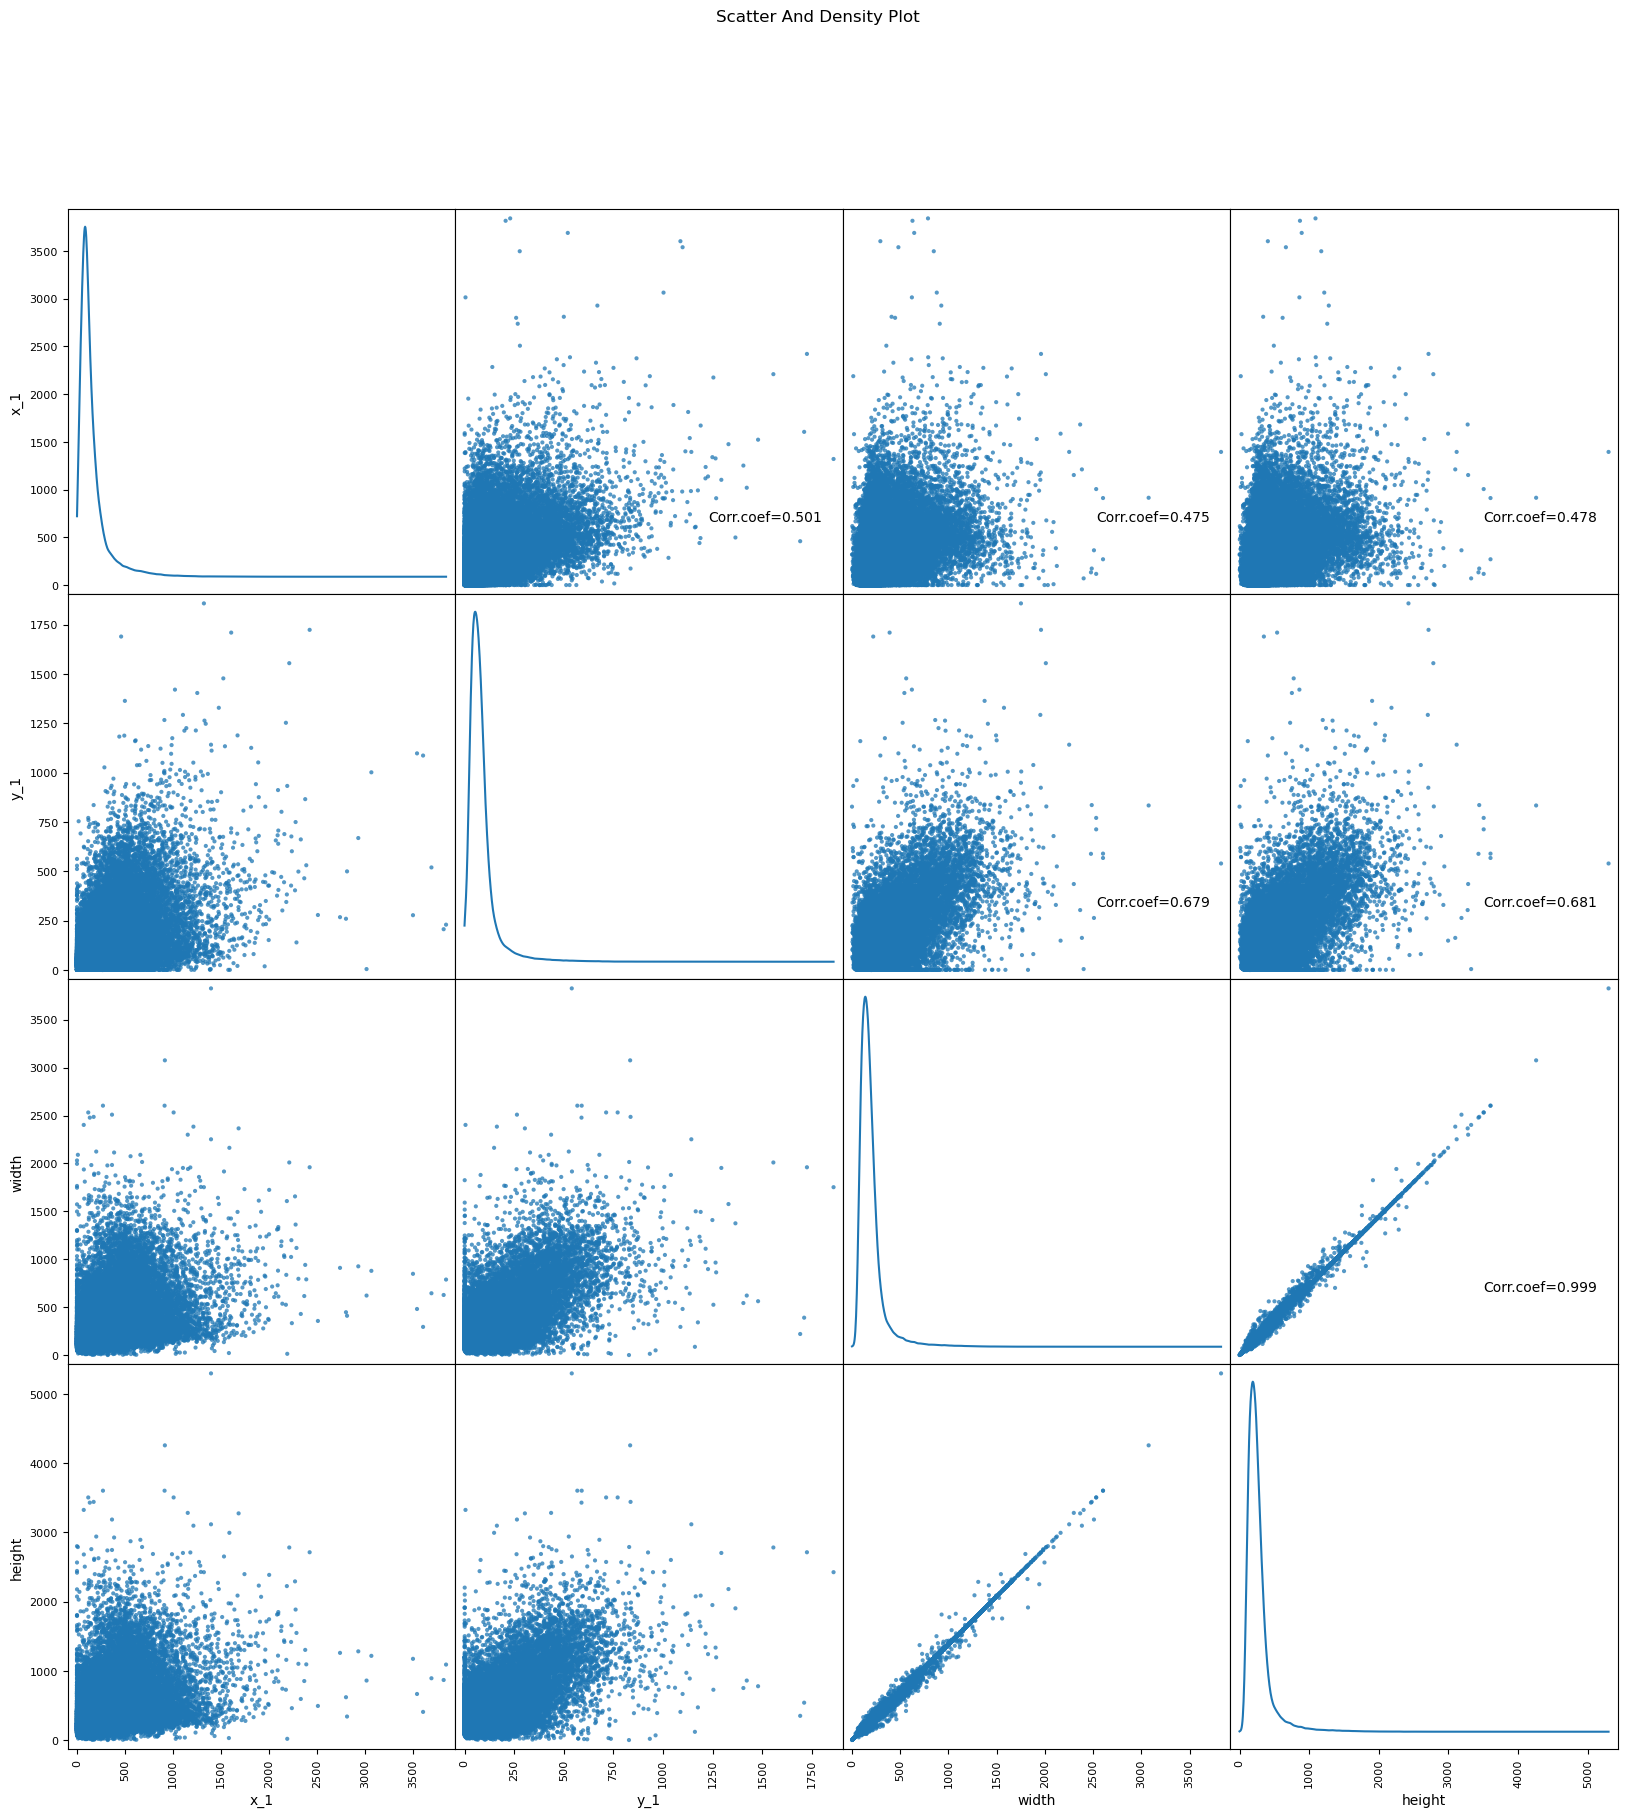

In [33]:
#Scatter and density plots
plotscattermatrix(df_bbox, 20, 10)

Bounding Boxes On Random Images

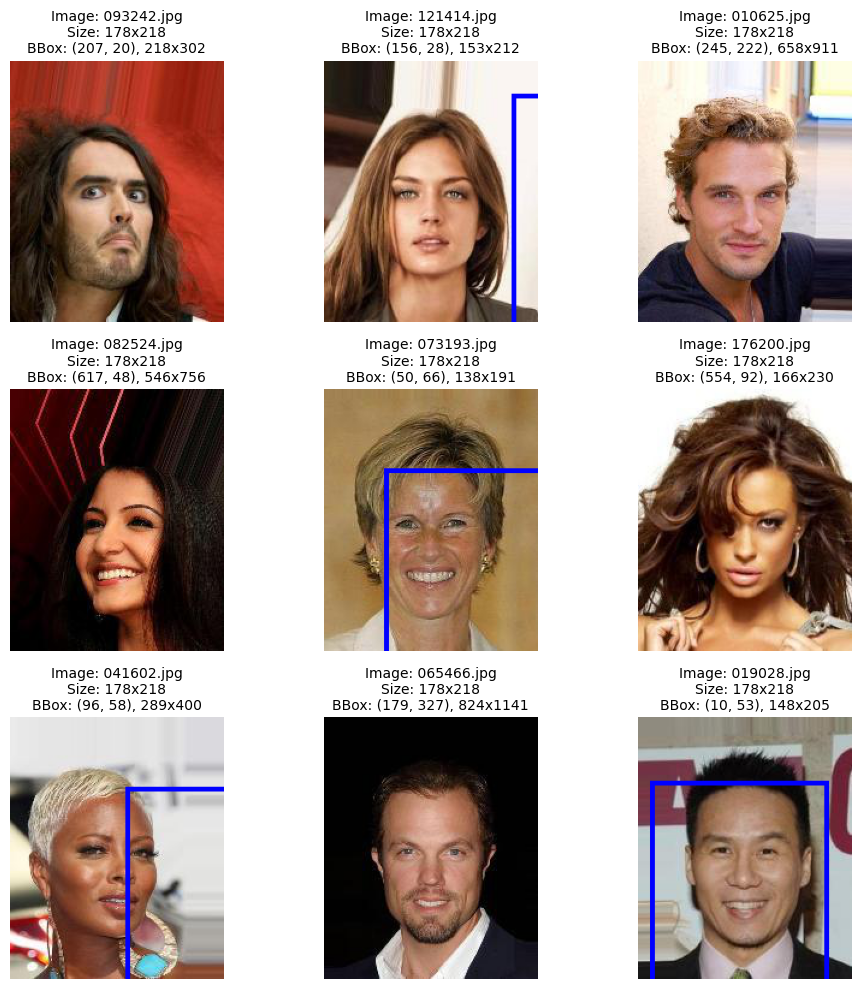

In [35]:
def plot_image_with_bbox(ax, row):
    #Load the image
    image_path=os.path.join(folder_path, row['image_id'])
    img=Image.open(image_path)
    #Get the image size (width, height)
    img_size=img.size
    #Create a draw object
    draw=ImageDraw.Draw(img)
    #Calculate the bottom right corner 
    x1=row['x_1']
    y1=row['y_1']
    width=row['width']
    height=row['height']
    x2=x1+width
    y2=y1+height
    #Check if coordinates are valid
    if x1<x2 and y1<y2:
        #Draw the bounding box (x1, y1, x2, y2)
        draw. rectangle ([x1, y1, x2, y2], outline = 'blue', width = 4)
    #Plot the image on the axis
    ax.imshow(img)
    ax.set_title(f"Image: {row['image_id']}\nSize: {img_size[0]}x{img_size[1]}\nBBox: ({x1}, {y1}), {width}x{height}", fontsize=10)
    #Turn off axis labels for better visualization
    ax.axis('off')
#Select a random subset of rows from dataframe
sampled_df=df_bbox.sample(n=9, random_state=42)
#Create a 3x3 subplot
fig, axs=plt.subplots(3,3,figsize=(10,10))
#Loop through the samples rows and plot the images with bounding boxes
for ax, (_ , row) in zip (axs.flatten(), sampled_df.iterrows()):
    plot_image_with_bbox(ax, row)
#Adjust layout
plt.tight_layout()
plt.show()

#file list_bbox_celeba.csv have many errors, cant use this file

In [37]:
df_eval

,image_id,partition
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,0
3,000004.jpg,0
4,000005.jpg,0
...,...,...
202594,202595.jpg,2
202595,202596.jpg,2
202596,202597.jpg,2
202597,202598.jpg,2


In [38]:
#Display count by partition
# 0 -> TRAINING
# 1 -> VALIDATION
# 2 -> TEST
df_eval['partition'].value_counts().sort_index()

partition
0    162770
1     19867
2     19962
Name: count, dtype: int64

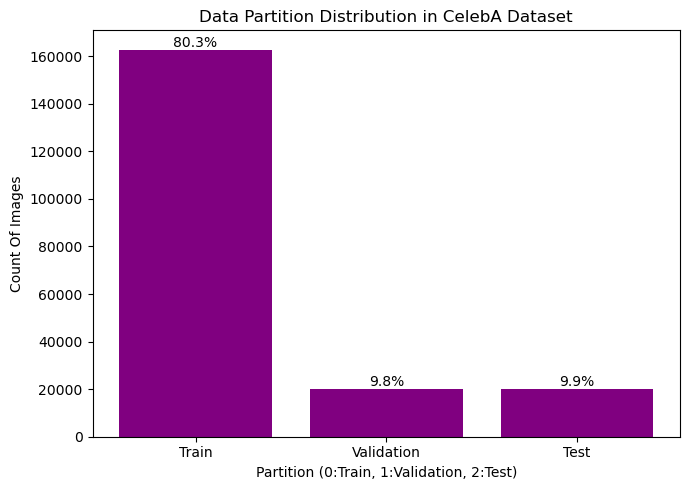

In [39]:
#Count the occurrences of each partition
partition_counts=df_eval['partition'].value_counts()
total_count=partition_counts.sum()
percentages=(partition_counts/total_count)*100
plt.figure(figsize=(7,5))
bars=plt.bar(partition_counts.index, partition_counts, color='purple')
#Add percentages on top of the bars
for bar, percentage in zip(bars, percentages):
    yval=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval, f'{percentage:.1f}%', ha='center', va='bottom')
plt.title('Data Partition Distribution in CelebA Dataset')
plt.xlabel('Partition (0:Train, 1:Validation, 2:Test)')
plt.ylabel('Count Of Images')
plt.xticks(ticks=[0,1,2], labels=['Train', 'Validation', 'Test'], rotation=0)
plt.tight_layout()
plt.show()

In [40]:
df_landmarks

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,66,114,112,112,86,119,71,147,104,150
...,...,...,...,...,...,...,...,...,...,...,...
202594,202595.jpg,69,111,108,111,89,140,73,151,104,153
202595,202596.jpg,67,112,110,112,85,141,66,150,110,150
202596,202597.jpg,69,111,107,111,92,137,68,151,109,153
202597,202598.jpg,69,111,108,111,90,137,71,153,106,151


In [41]:
df_landmarks.describe()

,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
count,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000
mean,69.353867,111.197982,107.644031,111.161600,88.063140,135.102024,71.247459,152.113011,105.586429,152.194660
std,1.717952,1.129284,1.690252,1.169229,6.647733,4.245078,3.168011,1.799343,3.233125,1.752368
min,56.000000,98.000000,90.000000,95.000000,57.000000,93.000000,57.000000,116.000000,82.000000,114.000000
25%,68.000000,111.000000,107.000000,111.000000,84.000000,133.000000,69.000000,151.000000,103.000000,151.000000
50%,69.000000,111.000000,108.000000,111.000000,88.000000,135.000000,72.000000,152.000000,105.000000,152.000000
75%,70.000000,112.000000,109.000000,112.000000,92.000000,138.000000,73.000000,153.000000,108.000000,153.000000
max,88.000000,129.000000,124.000000,122.000000,121.000000,156.000000,90.000000,174.000000,120.000000,173.000000


/Users/steffidorothy/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


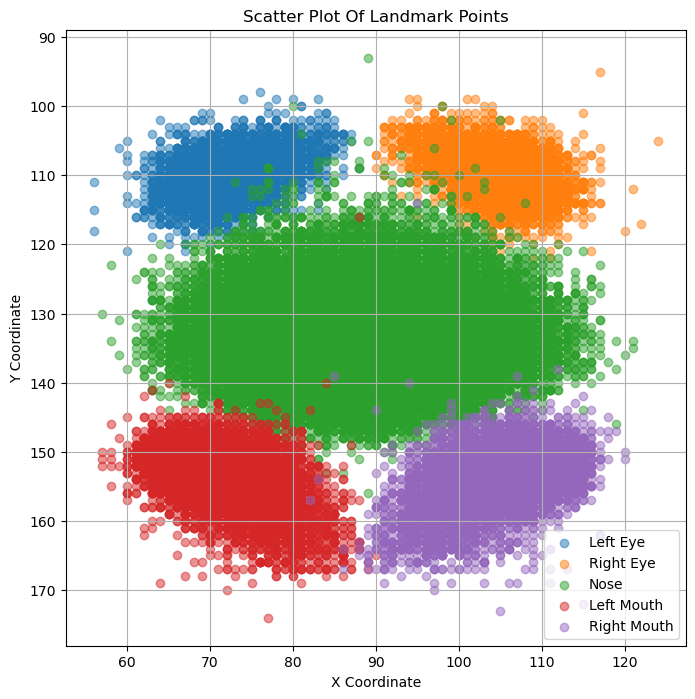

In [42]:
#Scatter plot of landmark points
plt.figure(figsize=(8,8))
plt.scatter(df_landmarks['lefteye_x'], df_landmarks['lefteye_y'], alpha=0.5, label='Left Eye')
plt.scatter(df_landmarks['righteye_x'], df_landmarks['righteye_y'], alpha=0.5, label='Right Eye')
plt.scatter(df_landmarks['nose_x'], df_landmarks['nose_y'], alpha=0.5, label='Nose')
plt.scatter(df_landmarks['leftmouth_x'], df_landmarks['leftmouth_y'], alpha=0.5, label='Left Mouth')
plt.scatter(df_landmarks['rightmouth_x'], df_landmarks['rightmouth_y'], alpha=0.5, label='Right Mouth')
plt.title('Scatter Plot Of Landmark Points')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
#Invert y axis
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.show()

The images are close-up shots of faces, so the landmark points are located in fixed areas of the images

In [326]:
path_celeb = []
for path in os.listdir(folder_path):
    if '.jpg' in path:
        path_celeb.append(os.path.join(folder_path, path))
new_path=path_celeb[0:2000]
len(new_path)

2000

In [570]:
crop = (30, 55, 150, 175) #croping size for the image so that only the face at centre is obtained
images = [np.array((Image.open(path).crop(crop)).resize((128,128))) for path in new_path]

for i in range(len(images)):
    images[i] = ((images[i] - images[i].min())/(255 - images[i].min()))
    #images[i] = images[i]*2-1 
    
images = np.array(images)

<Figure size 1000x1000 with 0 Axes>

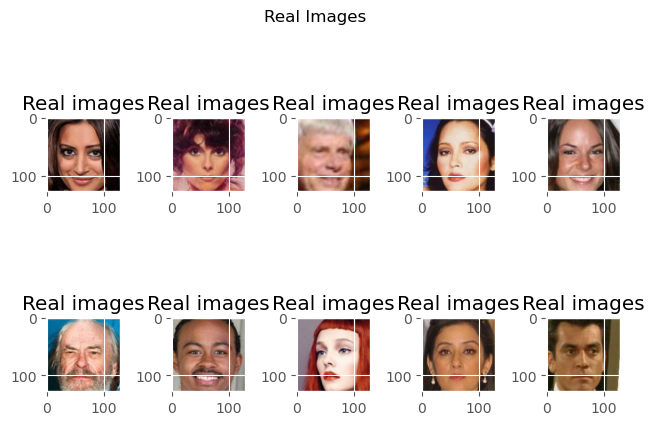

In [576]:
plt.figure(figsize=(10, 10))
fig, ax = plt.subplots(2, 5)
fig.suptitle('Real Images')
start_idx=800
num_images=2000
  # Ensure index stays within bounds
max_idx = min(start_idx + num_images - 1, len(images) - 1)
for i in range(2):
    for j in range(5):
      idx = start_idx + i * 5 + j
      if idx <= max_idx:
        ax[i, j].imshow(images[idx].reshape(128, 128, 3))
        ax[i, j].set_title('Real images')
      else:
        ax[i, j].axis('off')  # Hide empty subplots

plt.tight_layout()
plt.show()

Data Preprocessing

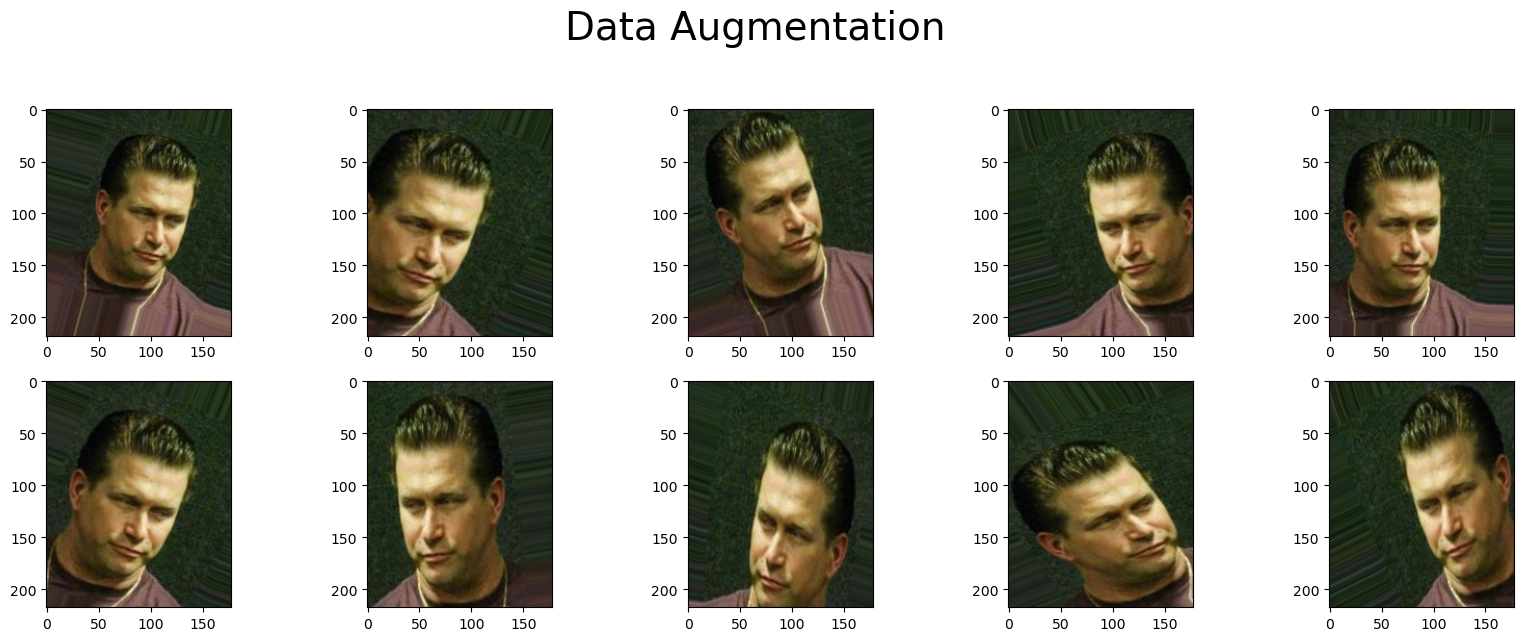

In [159]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import load_img, img_to_array
datagen =  ImageDataGenerator(
  #preprocessing_function=preprocess_input,
  rotation_range=30,
  width_shift_range=0.2,
  height_shift_range=0.2,
  shear_range=0.2,
  zoom_range=0.2,
  horizontal_flip=True
)

# load one image and reshape
img = load_img(img_path)
x = img_to_array(img)/255.
x = x.reshape((1,) + x.shape)

# plot 10 augmented images of the loaded iamge
plt.figure(figsize=(20,10))
plt.suptitle('Data Augmentation', fontsize=28)

i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.subplot(3, 5, i+1)
    plt.grid(False)
    plt.imshow( batch.reshape(218, 178, 3))
    
    if i == 9:
        break
    i += 1
    
plt.show()

In [544]:
def load_reshape_img(fname):
    img = load_img(fname)
    x = img_to_array(img)/255.
    x = x.reshape((1,) + x.shape)

    return x


def generate_df(partition, attr, num_samples):
    df_ = merged_df[(merged_df['partition'] == partition) & (merged_df[attr] == 0)]
    if not df_.empty:  # Check if filtered DataFrame is empty
        df_ = df_.sample(int(num_samples/2))
    df_ = pd.concat([df_,
                       merged_df[(merged_df['partition'] == partition) & (merged_df[attr] == 1)].sample(int(num_samples/2))])
    return df_

    # for Train and Validation
    if partition != 2:
        x_ = np.array([load_reshape_img(images_folder + fname) for fname in df_.index])
        x_ = x_.reshape(x_.shape[0], 218, 178, 3)
        y_ = np_utils.to_categorical(df_[attr],2)
    # for Test
    else:
        x_ = []
        y_ = []

        for index, target in df_.iterrows():
            im = cv2.imread(images_folder + index)
            im = cv2.resize(cv2.cvtColor(im, cv2.COLOR_BGR2RGB), (IMG_WIDTH, IMG_HEIGHT)).astype(np.float32) / 255.0
            im = np.expand_dims(im, axis =0)
            x_.append(im)
            y_.append(target[attr])

    return x_, y_

# Train data
x_train, y_train = generate_df(0, 'Male', TRAINING_SAMPLES)

# Train - Data Preparation - Data Augmentation with generators
train_datagen =  ImageDataGenerator(
  preprocessing_function=preprocess_input,
  rotation_range=30,
  width_shift_range=0.2,
  height_shift_range=0.2,
  shear_range=0.2,
  zoom_range=0.2,
  horizontal_flip=True,
)

train_datagen.fit(x_train)

train_generator = train_datagen.flow(
x_train, y_train,
batch_size=BATCH_SIZE,
)

In [546]:
# Train data
x_train, y_train = generate_df(0, 'Male', TRAINING_SAMPLES)

# Train - Data Preparation - Data Augmentation with generators
train_datagen =  ImageDataGenerator(
  preprocessing_function=preprocess_input,
  rotation_range=30,
  width_shift_range=0.2,
  height_shift_range=0.2,
  shear_range=0.2,
  zoom_range=0.2,
  horizontal_flip=True,
)

train_datagen.fit(x_train)

train_generator = train_datagen.flow(
x_train, y_train,
batch_size=BATCH_SIZE,
)

ValueError: too many values to unpack (expected 2)

In [580]:
fname=images
def load_reshape_img(fname):
    """Loads an image, converts it to a NumPy array, normalizes, and reshapes."""
    try:
        img = load_img(fname, target_size=(IMG_WIDTH, IMG_HEIGHT))  # Load and resize
        x = img_to_array(img) / 255.0  # Convert to array and normalize
        x = np.expand_dims(x, axis=0)  # Add batch dimension
        return x
    except OSError:
        print(f"Error loading image: {fname}")
        return None  # Handle loading errors gracefully


def generate_df(partition, attr, num_samples):
    """Filters and samples data from the DataFrame."""
    df_filtered = merged_df[(merged_df['partition'] == partition) & (merged_df[attr] == 0)]
    if not df_filtered.empty:
        df_filtered = df_filtered.sample(int(num_samples / 2))

    df_ = pd.concat([df_filtered,
                     merged_df[(merged_df['partition'] == partition) & (merged_df[attr] == 1)].sample(int(num_samples / 2))])
    return df_


def generate_data(partition, attr, num_samples):
    """Generates image and label data for training or validation."""
    df_ = generate_df(partition, 'Male', num_samples)

    if partition != 2:  # Training/Validation
        x_ = np.empty((num_samples, IMG_HEIGHT, IMG_WIDTH, 3))  # Pre-allocate memory for efficiency
        y_ = to_categorical(df_[attr], 2)
        for i, (index, row) in enumerate(df_.iterrows()):
            x_[i] = load_reshape_img(images_folder + fname)  # Use 'image_path' column
            if x_[i] is None:  # Handle loading errors
                continue
        return x_, y_

    else:  # Test
        x_ = []
        y_ = []
        for index, target in df_.iterrows():
            im = cv2.imread(images_folder + index)
            if im is None:  # Handle loading errors
                print(f"Error loading image: {images_folder + index}")
                continue
            im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
            im = cv2.resize(im, (IMG_WIDTH, IMG_HEIGHT)).astype(np.float32) / 255.0
            im = np.expand_dims(im, axis=0)
            x_.append(im)
            y_.append(target[attr])
        return np.array(x_), np.array(y_)  # Convert lists to NumPy arrays


# Train data
x_train, y_train = generate_data(0, 'Male',TRAINING_SAMPLES)  # Use generate_data for consistency

# Train - Data Preparation - Data Augmentation with generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

train_datagen.fit(x_train)

train_generator = train_datagen.flow(
    x_train, y_train,
    batch_size=BATCH_SIZE,
)

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('<U63'), dtype('float64')) -> None